Introduction: https://aiml4os.github.io/funathon-project2/
Supervised learning: https://aiml4os.github.io/funathon-project2/1-ttc.html
RAG approach - Introduction: https://aiml4os.github.io/funathon-project2/2-rag-intro.html 
RAG pipeline approach - Create a vector database: https://aiml4os.github.io/funathon-project2/2-rag-vdb 

# Project 2: Automatic coding for NACE classification

In [1]:
# uv sync

## Introduction

### 2.6 Run code interactively (optional but recommended)

<Axes: xlabel='code'>

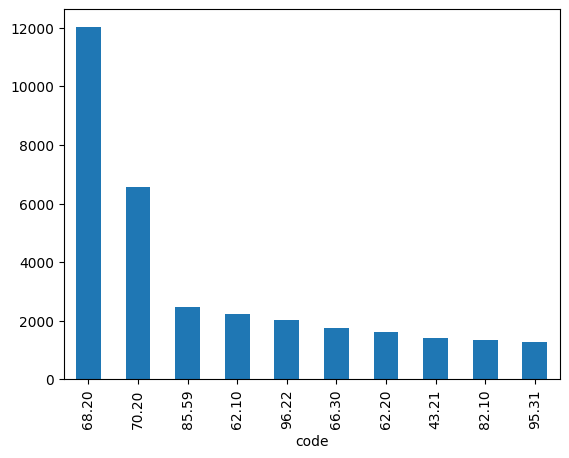

In [2]:
# %%
# If you need to change working directory (default is your interactive .py file location)
# import os
# os.chdir("<NEW_RELATIVE_LOCATION>")

import pandas as pd

df = pd.read_parquet(
    "https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet"
)
df.head()

# %%
df["code"].value_counts().head(10).plot(kind="bar")

## Supervised approach using TorchTextClassifiers

### 2 Load the data

#### 2.1 Question 1 — Import libraries and load environment variables

In [3]:
import mlflow
from dotenv import load_dotenv

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv(override=True)

True

#### 2.2 Question 2 — Load the dataset from s3

In [5]:
import polars as pl

In [6]:
df = pl.read_parquet(
    "https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet"
)
print(df.head())
print(f"Total rows: {len(df)}")

shape: (5, 3)
┌───────┬─────────────────────────────────┬─────────────────────────────────┐
│ code  ┆ name                            ┆ label                           │
│ ---   ┆ ---                             ┆ ---                             │
│ str   ┆ str                             ┆ str                             │
╞═══════╪═════════════════════════════════╪═════════════════════════════════╡
│ 01.11 ┆ Growing of cereals, other than… ┆ Pulses cultivation for market   │
│ 01.11 ┆ Growing of cereals, other than… ┆ Legume crop production activit… │
│ 01.11 ┆ Growing of cereals, other than… ┆ Broad bean farming operations   │
│ 01.11 ┆ Growing of cereals, other than… ┆ Chickpea harvesting and proces… │
│ 01.11 ┆ Growing of cereals, other than… ┆ Production of dried beans and … │
└───────┴─────────────────────────────────┴─────────────────────────────────┘
Total rows: 70000


#### 2.3 Question 3 — Count unique NACE codes

In [7]:
n_classes = df["code"].n_unique()
print(f"Number of unique NACE codes: {n_classes}")

Number of unique NACE codes: 311


### 3 Split the data

#### 3.1 Question 1 — Split the dataset into train / validation / test sets

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
train_df, tmp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df  = train_test_split(tmp_df, test_size=0.50, random_state=42)

X_train, y_train = train_df["label"].to_numpy(), train_df["code"].to_numpy()
X_val, y_val = val_df["label"].to_numpy(), val_df["code"].to_numpy()
X_test, y_test = test_df["label"].to_numpy(), test_df["code"].to_numpy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 49000 | Val: 10500 | Test: 10500


#### 3.2 Question 2 — Encode the labels

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
encoder = LabelEncoder()
encoder.fit(train_df["code"].to_numpy())

LabelEncoder()

In [12]:
all_codes  = set(df['code'])
train_codes = set(train_df['code'])
missing = all_codes - train_codes

if missing:
    print(f"WARNING: {len(missing)} code(s) missing from training set: {missing}")
else:
    print(f"OK — all {len(all_codes)} codes appear in the training set.")

OK — all 311 codes appear in the training set.


#### 3.3 Question 3 — Prepare the labels to use them with ttc

In [13]:
# !pip install torchTextClassifiers

In [14]:
# %pip install git+https://github.com/InseeFrLab/torchTextClassifiers.git

In [15]:
from torchTextClassifiers.value_encoder import ValueEncoder

In [16]:
value_encoder = ValueEncoder(label_encoder=encoder)

### 4 Applying a tokenizer

#### 4.3 Question 1 — Train the tokenizer and inspect a sample

In [17]:
# !pip install tokenizers transformers

In [18]:
import sys

for module_name in list(sys.modules):
    if module_name == "torchTextClassifiers.tokenizers" or module_name.startswith(
        "torchTextClassifiers.tokenizers."
    ):
        del sys.modules[module_name]

from torchTextClassifiers.tokenizers import HAS_HF, WordPieceTokenizer

print("HAS_HF:", HAS_HF)


HAS_HF: True


In [19]:
tokenizer = WordPieceTokenizer(vocab_size=5000, output_dim=10)
tokenizer.train(X_train)

In [20]:
print("Output tensor size:", tokenizer.tokenize(X_train[0]).input_ids.shape)
print("Vocabulary size:", tokenizer.vocab_size)

# Look at an example of tokenization
print("Raw text", X_train[0])
print(
    "Tokens id:",
    tokenizer.tokenize(X_train[0]).input_ids.squeeze(0)
)
print(
    "Tokens:",
    tokenizer.tokenizer.convert_ids_to_tokens(
        tokenizer.tokenize(X_train[0]).input_ids.squeeze(0)
    )
)

Output tensor size: torch.Size([1, 10])
Vocabulary size: 5000
Raw text Real estate portfolio management
Tokens id: tensor([  3, 190, 206, 317, 137,   2,   1,   1,   1,   1])
Tokens: ['[SEP]', 'real', 'estate', 'portfolio', 'management', '[CLS]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


### 6 Training

#### 6.1 Question 1 — Create the classifier

In [21]:
from torchTextClassifiers import ModelConfig, TrainingConfig, torchTextClassifiers

In [22]:
embedding_dim = 96

model_config = ModelConfig(
    embedding_dim=embedding_dim,
    num_classes=n_classes,)

ttc = torchTextClassifiers(
    tokenizer=tokenizer,
    model_config=model_config,
    value_encoder=value_encoder,
)

2026-05-28 07:23:02 - torchTextClassifiers.model.model - 🔹 No categorical variable network provided; using only text embeddings.


#### 6.2 Question 2 — Prepare training

In [23]:
training_config = TrainingConfig(
    num_epochs=1,
    batch_size=128,
    lr=5 * 1e-4,
    patience_early_stopping=5,
)

#### 6.3 Question 3 — Train on a small subsample

In [24]:
mlflow.set_experiment("funathon-2026-project2")
mlflow.pytorch.autolog()

with mlflow.start_run() as run:
    # This should take approximately 1-2mn
    ttc.train(
        X_train,
        y_train,
        training_config=training_config,
        X_val=X_val,
        y_val=y_val,
        verbose=True,
    )

    mlflow.log_artifacts(
        training_config.save_path,   # local folder produced by ttc.train()
        artifact_path="model_artifacts",
    )

2026-05-28 07:23:03 - torchTextClassifiers.torchTextClassifiers - Starting training process...
2026-05-28 07:23:03 - torchTextClassifiers.torchTextClassifiers - Running on: cpu
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/opt/python/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments pla

┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model       │ TextClassificationModel │  510 K │ train │     0 │
│ 1 │ loss        │ CrossEntropyLoss        │      0 │ train │     0 │
│ 2 │ accuracy_fn │ MulticlassAccuracy      │      0 │ train │     0 │
└───┴─────────────┴─────────────────────────┴────────┴───────┴───────┘

Trainable params: 510 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 510 K                                                                                                
Total estimated model params size (MB): 2.041                                                                      
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/opt/python/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/opt/python/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/opt/python/lib/python3.13/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` 
from an ambiguous collection. The batch size we found is 128. To avoid any miscalculations, use `self.log(..., 
batch_size=batch_size)`.

/opt/python/lib/python3.13/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` 
from an ambiguous collection. The batch size we found is 104. To avoid any miscalculations, use `self.log(..., 
batch_size=batch_size)`.

/opt/python/lib/python3.13/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` 
from an ambiguous collection. The batch size we found is 4. To avoid any miscalculations, use `self.log(..., 
batch_size=batch_size)`.

`Trainer.fit` stopped: `max_epochs=1` reached.


2026/05/28 07:23:41 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/28 07:23:41 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/onyxia/work/funathon-project2
2026/05/28 07:23:41 INFO mlflow.utils.environment: Detected uv project at /home/onyxia/work/funathon-project2. Attempting to export requirements via 'uv export'.
2026/05/28 07:23:41 INFO mlflow.utils.uv_utils: Exported 186 dependencies via uv
2026/05/28 07:23:41 INFO mlflow.utils.environment: Successfully exported 186 requirements from uv project. Skipping package capture based inference.
2026/05/28 07:23:41 INFO mlflow.utils.uv_utils: Extracted 1 private index URL(

🏃 View run trusting-sheep-119 at: https://user-dstjck-mlflow.user.lab.sspcloud.fr/#/experiments/1/runs/f2de8d59e0814654a4bc8182061a7ca3
🧪 View experiment at: https://user-dstjck-mlflow.user.lab.sspcloud.fr/#/experiments/1


### 7 Prediction and explainability

#### 7.1 Question 0 — Load the pretrained model from MLflow

In [25]:
import s3fs

fs = s3fs.S3FileSystem(
    anon=True,  # public bucket
    endpoint_url="https://minio.lab.sspcloud.fr",
)

local_dir = "./mlflow-artifacts/"
fs.get(
    "projet-funathon/diffusion/mlflow-artifacts/",
    local_dir,
    recursive=True,
)
# Rebuild the torchTextClassifiers object from the downloaded files
ttc = torchTextClassifiers.load(local_dir)

ttc.pytorch_model.eval()

2026-05-28 07:23:48 - torchTextClassifiers.model.model - 🔹 No categorical variable network provided; using only text embeddings.
2026-05-28 07:23:48 - torchTextClassifiers.torchTextClassifiers - Model checkpoint loaded from mlflow-artifacts/model_checkpoint.ckpt
2026-05-28 07:23:48 - torchTextClassifiers.torchTextClassifiers - Model loaded successfully from mlflow-artifacts


TextClassificationModel(
  (token_embedder): TokenEmbedder(
    (embedding_layer): Embedding(5000, 96, padding_idx=1)
  )
  (sentence_embedder): SentenceEmbedder(
    (label_attention_module): LabelAttention(
      (label_embeds): Embedding(311, 96)
      (c_q): Linear(in_features=96, out_features=96, bias=False)
      (c_k): Linear(in_features=96, out_features=96, bias=False)
      (c_v): Linear(in_features=96, out_features=96, bias=False)
      (c_proj): Linear(in_features=96, out_features=96, bias=False)
    )
  )
  (classification_head): ClassificationHead(
    (net): Linear(in_features=96, out_features=1, bias=True)
  )
)

#### 7.2 Question 1 — Generate top-5 predictions with confidence score

In [31]:
import random

In [ ]:
# !pip install captum

In [32]:
import sys
import captum
from captum.attr import LayerIntegratedGradients

print("Python:", sys.executable)
print("Captum version:", captum.__version__)
print("Captum imported successfully.")

Python: /opt/python/bin/python
Captum version: 0.9.0
Captum imported successfully.


In [33]:
import importlib
from captum.attr import LayerIntegratedGradients

# Reload the specific module where HAS_CAPTUM is defined
ttc_module = importlib.import_module(
    "torchTextClassifiers.torchTextClassifiers"
)

print("Before reload:", ttc_module.HAS_CAPTUM)

importlib.reload(ttc_module)

print("After reload:", ttc_module.HAS_CAPTUM)


Before reload: True
After reload: True


In [34]:
random_indices = random.sample(range(len(X_test)), 3)
example_texts = X_test[random_indices]
example_true_codes = y_test[random_indices]
print(example_texts)
top_k = 5
results = ttc.predict(example_texts, top_k=top_k, explain_with_captum=True)
for i, text in enumerate(example_texts):
    predicted_codes = [results["prediction"][i][k] for k in range(top_k)]
    confidence = [results["confidence"][i][k].item() for k in range(top_k)]
    print(f"\nText: {text}")
    print(f"  True code: {example_true_codes[i]}")
    for code, conf in zip(predicted_codes, confidence):
        print(f"  {code}  (confidence: {conf:.3f})")

['Parquet floor sanding services'
 'Orthodontic appliance fitting and adjustment'
 'Detailed building layout specifications']

Text: Parquet floor sanding services
  True code: 43.33
  43.33  (confidence: 1.000)
  66.21  (confidence: 0.000)
  10.82  (confidence: 0.000)
  53.10  (confidence: 0.000)
  79.12  (confidence: 0.000)

Text: Orthodontic appliance fitting and adjustment
  True code: 86.23
  86.23  (confidence: 1.000)
  63.10  (confidence: 0.000)
  80.01  (confidence: 0.000)
  13.99  (confidence: 0.000)
  87.99  (confidence: 0.000)

Text: Detailed building layout specifications
  True code: 71.11
  71.11  (confidence: 0.500)
  68.20  (confidence: 0.220)
  62.20  (confidence: 0.040)
  77.32  (confidence: 0.030)
  96.22  (confidence: 0.020)


##### Eget eksempel (fra Karina)

In [36]:
import numpy as np

random_indices = random.sample(range(len(X_test)), 3)
#example_texts = X_test[random_indices]
#example_true_codes = y_test[random_indices]
example_texts = ['construction of airfield runways', 'construction of electricity overhead lines', 'rental of and activities related to own or leased real estate']
example_true_codes = ['42.11', '42.12', '68.20']

ex_X_test = np.array(example_texts).reshape(-1, 1)

print(example_texts)
top_k = 5
# results = ttc.predict(example_texts, top_k=top_k, explain_with_captum=True)
results = ttc.predict(ex_X_test, top_k=top_k, explain_with_captum=True)

for i, text in enumerate(example_texts):
    predicted_codes = [results["prediction"][i][k] for k in range(top_k)]
    confidence = [results["confidence"][i][k].item() for k in range(top_k)]
    print(f"\nText: {text}")
    print(f"  True code: {example_true_codes[i]}")
    for code, conf in zip(predicted_codes, confidence):
        print(f"  {code}  (confidence: {conf:.3f})")


['construction of airfield runways', 'construction of electricity overhead lines', 'rental of and activities related to own or leased real estate']

Text: construction of airfield runways
  True code: 42.11
  17.25  (confidence: 0.360)
  43.41  (confidence: 0.160)
  42.21  (confidence: 0.120)
  28.12  (confidence: 0.080)
  86.91  (confidence: 0.070)

Text: construction of electricity overhead lines
  True code: 42.12
  42.22  (confidence: 0.860)
  55.20  (confidence: 0.080)
  25.61  (confidence: 0.050)
  43.99  (confidence: 0.000)
  30.92  (confidence: 0.000)

Text: rental of and activities related to own or leased real estate
  True code: 68.20
  77.22  (confidence: 0.460)
  77.21  (confidence: 0.150)
  77.32  (confidence: 0.080)
  68.20  (confidence: 0.080)
  77.11  (confidence: 0.060)


#### 7.3 Question 2 — Visualise word attributions for the top prediction

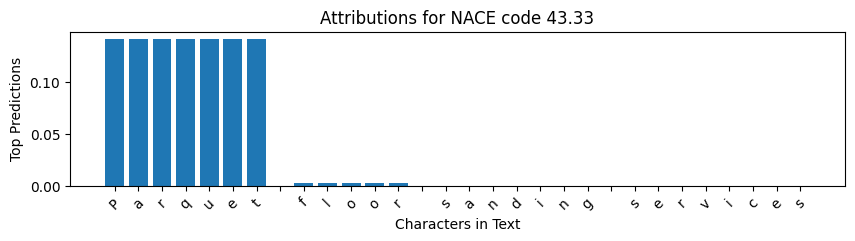

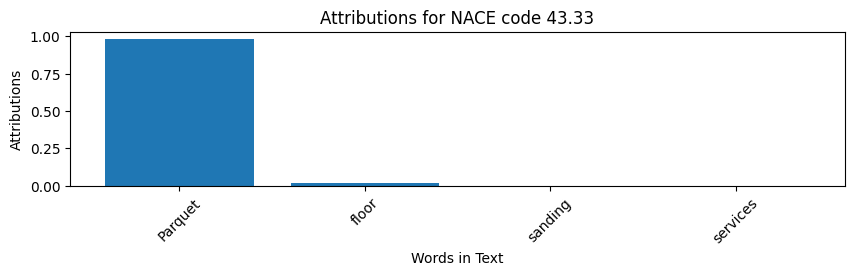

In [35]:
from torchTextClassifiers.utilities.plot_explainability import (
    map_attributions_to_char, map_attributions_to_word,
    plot_attributions_at_char, plot_attributions_at_word, figshow,
)

text_idx = 0
top_k_idx = 0
text_sample         = example_texts[text_idx]
offsets             = results["offset_mapping"][text_idx]
word_ids            = results["word_ids"][text_idx]
predicted_code = results["prediction"][text_idx][top_k_idx]

attributions  = results["captum_attributions"][text_idx][top_k_idx] # (seq_len,)

words, word_attributions = map_attributions_to_word(
    attributions.unsqueeze(0), text_sample, word_ids, offsets
)
char_attributions = map_attributions_to_char(attributions.unsqueeze(0), offsets, text_sample)

titles = [f"Attributions for NACE code {predicted_code}"]

figshow(plot_attributions_at_char(
    text=text_sample, attributions_per_char=char_attributions, titles=titles,
)[0])

figshow(plot_attributions_at_word(
    text=text_sample, words=words.values(), attributions_per_word=word_attributions, titles=titles,
)[0])

#### 7.4 Question 3 — Evaluate accuracy on the test set

In [37]:
results_test = ttc.predict(X_test, top_k=1)
preds    = results_test["prediction"].squeeze(1)
accuracy = (preds == y_test).mean()
print(f"Test accuracy: {accuracy:.4f} ({int(accuracy * len(y_test))}/{len(y_test)} correct)")

Test accuracy: 0.8737 (9174/10500 correct)


## RAG approach - Introduction

### 2 What will you learn in this tutorial?

#### 2.1.1 Simple pseudocode

In [38]:
query_text = "industrial bakery"
query_vector = llm_lab.embeddings.create(
    model='qwen3-embedding-8b', input=query_text
).data[0].embedding

hits = qdrant_client.search(
    collection_name='nace_vdb', query_vector=query_vector, limit=5
)
context = "\n".join([hit.payload['text'] for hit in hits])

prompt = f"Use the following context to answer the question:\n{context}\nQuestion: {query_text}\nAnswer:"
result = llm_lab.chat.completions.create(
    model='gpt-oss:20b',
    messages=[{'role': 'user', 'content': prompt}]
)
print(result.choices[0].message.content)

NameError: name 'llm_lab' is not defined

### 3 Technical requirements

#### 3.3 Loading credentials in Python

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import os
try:
    QDRANT_URL = os.environ["QDRANT_URL"]
    print("QDRANT_URL loaded successfully")
except KeyError:
    raise ValueError("QDRANT_URL is not set — check your .env file")

QDRANT_URL loaded successfully


## RAG pipeline approach - Create a vector database

### Prepare your environment
### Exercise 1: Connections

#### Question 0

In [1]:
import os
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

#### Question 1 + 2

In [3]:
# !pip install openai

In [4]:
from openai import OpenAI

In [5]:
client_llmlab = OpenAI(
    base_url=os.environ["LLMLAB_URL"],
    api_key=os.environ["LLMLAB_API_KEY"],
)

# Print models list
models = client_llmlab.models.list()
for model in models.data:
    print(f"ID: {model.id}")

ID: gemma4-26b-moe
ID: qwen3-6-35b-moe
ID: qwen3-embedding-8b


#### Question 3

In [6]:
# !pip install qdrant_client

In [7]:
from qdrant_client import QdrantClient

In [8]:
client_qdrant = QdrantClient(
    url=os.environ["QDRANT_URL"],
    api_key=os.environ["QDRANT_API_KEY"],
    port=os.environ["QDRANT_API_PORT"],
    check_compatibility=False
)

collections = client_qdrant.get_collections()
for collection in collections.collections:
    print(collection.name)

### Get and process NACE data
### Exercise 2: handling NACE data

#### Question 1

In [10]:
import duckdb

In [11]:
con = duckdb.connect(database=":memory:")

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

path_nace = 'https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/NACE_Rev2.1_Structure_Explanatory_Notes_EN.tsv'
query_definition = f"SELECT * FROM read_csv('{path_nace}')"
table = con.execute(query_definition).to_arrow_table()
nace = table.to_pylist()

nace[22]

{'ORDER_KEY': 230,
 'ID': '014',
 'CODE': '01.4',
 'HEADING': 'Animal production',
 'PARENT_ID': '01',
 'PARENT_CODE': '01',
 'LEVEL': 3,
 'Implementation_rule': None,
 'Includes': 'This group includes:\\n- farming (husbandry, raising) and breeding of all animals, except aquatic animals',
 'IncludesAlso': None,
 'Excludes': 'This group excludes:\\n- farm animal boarding and care, see 01.62\\n- production of hides and skins from slaughterhouses, see 10.11'}

#### Question 2

In [14]:
from dataclasses import dataclass, field
from typing import Optional

In [15]:
def _clean(value) -> Optional[str]:
    """Normalize to stripped single-line string, or None if empty/missing."""
    if value is None:
        return None
    # str() handles non-string values (int, float...) from raw dicts
    # replace("\n", " ") flattens multiline strings to a single line
    # split() tokenizes on any whitespace, join(" ") rebuilds with single spaces
    cleaned = " ".join(str(value).replace("\n", " ").split())
    # Empty string is falsy in Python — return None instead for consistency
    return cleaned or None

@dataclass
class NaceDocument:
    code: str
    heading: str
    level: int
    parent_code: Optional[str] = None
    includes: Optional[str] = None
    includes_also: Optional[str] = None
    excludes: Optional[str] = None

    text: str = field(init=False)

    @classmethod
    def from_raw(cls, raw: dict, with_includes_also=True, with_excludes=False,) -> "NaceDocument":
        for key in ("CODE", "HEADING", "LEVEL"):
            if not raw.get(key):
                raise ValueError(f"Missing required field: {key}")

        level = int(raw["LEVEL"])
        if not (1 <= level <= 4):
            raise ValueError(f"Invalid level: {level}")

        obj = cls(
            code=str(raw["CODE"]).strip(),
            heading=_clean(raw["HEADING"]),
            level=level,
            parent_code=_clean(raw.get("PARENT_CODE")),
            includes=_clean(raw.get("Includes")),
            includes_also=_clean(raw.get("IncludesAlso")),
            excludes=_clean(raw.get("Excludes")),
        )

        obj.text = obj.to_embedding_text(
            with_includes_also=with_includes_also,
            with_excludes=with_excludes,
        )

        return obj

    def to_embedding_text(
        self,
        *,
        with_includes_also: bool = False,
        with_excludes: bool = False,
    ) -> str:
        parts = []

        parts.append(f"# Code: {self.code}")
        parts.append(f"# Title: {self.heading}")

        if self.includes:
            parts.append("")
            parts.append("## Includes:")
            parts.append(self.includes.strip())

        if with_includes_also and self.includes_also:
            parts.append("")
            parts.append("## Also includes:")
            parts.append(self.includes_also.strip())

        if with_excludes and self.excludes:
            parts.append("")
            parts.append("## Excludes:")
            parts.append(self.excludes.strip())

        output = "\n".join(parts)
        output = output.replace("\\n", "\n")

        return output.strip()

nace_documents = []
for nace_code in nace:
    nace_documents.append(
        NaceDocument.from_raw(
            raw=nace_code,
            with_includes_also=True,
            with_excludes=True
        )
    )

#### Question 3

In [16]:
from pprint import pprint

In [18]:
i = 22
print(f"Printing index {i}:")

print("=============================================")
print("=============================================")

nace_example = nace[i]
doc_example = NaceDocument.from_raw(nace_example)

print("\nPrinting text to embed (WITH exclusions):")
_ = doc_example.to_embedding_text(
    with_includes_also=True,
    with_excludes=True,
)
print(doc_example.text)

print("=============================================")
print("=============================================")

print("\nPrinting text to embed (WITHOUT exclusions):")
_ = doc_example.to_embedding_text(
    with_includes_also=True,
    with_excludes=False,
)
print(doc_example.text)

Printing index 22:

Printing text to embed (WITH exclusions):
# Code: 01.4
# Title: Animal production

## Includes:
This group includes:
- farming (husbandry, raising) and breeding of all animals, except aquatic animals

Printing text to embed (WITHOUT exclusions):
# Code: 01.4
# Title: Animal production

## Includes:
This group includes:
- farming (husbandry, raising) and breeding of all animals, except aquatic animals


JCK note: The first does not include any exclution. Are there any? 

### Embed your NACE text descriptions
### Exercise 3: create a Qdrant vector store and feed it with embedded NACE text descriptions

In [20]:
EMB_MODEL_NAME = "qwen3-embedding-8b"
emb_dim = 4096

#### Question 1

In [21]:
from qdrant_client.models import Distance, VectorParams

In [22]:
COLLECTION_NAME = "nace-collection"

# Delete the collection if necessary
if client_qdrant.collection_exists(collection_name=COLLECTION_NAME):
    client_qdrant.delete_collection(collection_name=COLLECTION_NAME)

# Create the collection
client_qdrant.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(
        size=emb_dim,
        distance=Distance.COSINE
    )
)

True

#### Question 2